# ERA5 orography with CORDEX analysis regions

This example loads the **ERA5 invariant geopotential** (`code 129`), converts it to
surface **orography** (height in metres), and overlays the outlines of the
**CORDEX-CMIP6 `*-11` analysis regions** defined in
`feather.util.regions`.

The region geometry comes straight from the framework, so the outlines here are
exactly the boxes/caps used for area-weighted regional statistics elsewhere in
Feather (e.g. the per-region Added Value bars).

> **Where to run:** loading the full-resolution ERA5 field (~540k points) and
> triangulating it for the map is too heavy for a Levante login node. Run this
> notebook on a compute node / Jupyter-on-compute session (`conda activate feather`).

In [1]:
# Keep BLAS from spawning a thread per core (avoids RLIMIT_NPROC errors on DKRZ).
import os
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from feather.util.regions import list_regions, get_region

G = 9.80665  # standard gravity (m s^-2), to turn geopotential into height

In [5]:
import cmocean as cmo

## 1. Load ERA5 orography

The invariant geopotential `z` (m² s⁻²) lives in the ERA5 pool on Levante. It is
stored on a 1-D **reduced-Gaussian** grid (dimension `values`, with 1-D
`latitude`/`longitude` coordinates), so we keep it as scattered points and plot
with `tricontourf` rather than `pcolormesh`.

`indexpath=""` stops `cfgrib` from trying to write a `.idx` file into the
read-only pool directory.

In [2]:
ERA5_OROG_GRIB = "/pool/data/ERA5/E5/sf/an/IV/129/E5sf00_IV_INVARIANT_129.grb"

ds = xr.open_dataset(
    ERA5_OROG_GRIB,
    engine="cfgrib",
    backend_kwargs={"indexpath": ""},
)

orog = (ds["z"] / G).rename("orography")  # geopotential -> height in metres
orog.attrs.update(long_name="Surface orography", units="m")

lon = orog["longitude"].values
lat = orog["latitude"].values
# Wrap to -180..180 so triangulation doesn't bridge the 0/360 seam.
lon = ((lon + 180.0) % 360.0) - 180.0

print(f"points: {orog.size:,}")
print(f"orography range: {float(orog.min()):.0f} .. {float(orog.max()):.0f} m")

points: 542,080
orography range: -190 .. 5900 m


## 2. Build CORDEX region outlines

Each CORDEX region in `feather.util.regions` is either:

* a **polygon** — a 4-corner quadrilateral (the geographic corners of the
  rotated-pole bounding box), or
* a **cap** — a polar latitude threshold (ARC north of ~48.6°N, ANT south of
  ~55.5°S).

We turn each region into `(lons, lats)` outline arrays plus a label anchor.
Polygon edges are drawn with a `Geodetic` transform so antimeridian-crossing
boxes (e.g. AUS) wrap correctly; caps are drawn as constant-latitude parallels.

In [3]:
def region_outline(name):
    """Return (lons, lats, transform, label_lon, label_lat) for a CORDEX region."""
    region = get_region(name)
    if region.kind == "polygon":
        corners = np.asarray(region.corners, dtype=float)
        lons = np.append(corners[:, 0], corners[0, 0])  # close the loop
        lats = np.append(corners[:, 1], corners[0, 1])
        # Geodetic edges handle dateline wrapping for rotated boxes.
        return lons, lats, ccrs.Geodetic(), float(corners[:, 0].mean()), float(corners[:, 1].mean())
    # cap: a full parallel at the threshold latitude
    lons = np.linspace(-180.0, 180.0, 361)
    lats = np.full_like(lons, region.cap_lat)
    label_lat = region.cap_lat + (6 if region.cap_side == "north" else -6)
    return lons, lats, ccrs.PlateCarree(), 0.0, label_lat


for name in list_regions():
    r = get_region(name)
    print(f"{name:4s} {r.kind:8s} {r.long_name}")

SAM  polygon  South America
CAM  polygon  Central America
NAM  polygon  North America
EUR  polygon  Europe
AFR  polygon  Africa
WAS  polygon  South Asia
EAS  polygon  East Asia
CAS  polygon  Central Asia
AUS  polygon  Australasia
MED  polygon  Mediterranean
MNA  polygon  Middle East and North Africa
SEA  polygon  South East Asia
ARC  cap      Arctic
ANT  cap      Antarctica


## 3. Plot

Orography as a filled terrain map (Robinson projection) with the CORDEX region
outlines and labels on top.

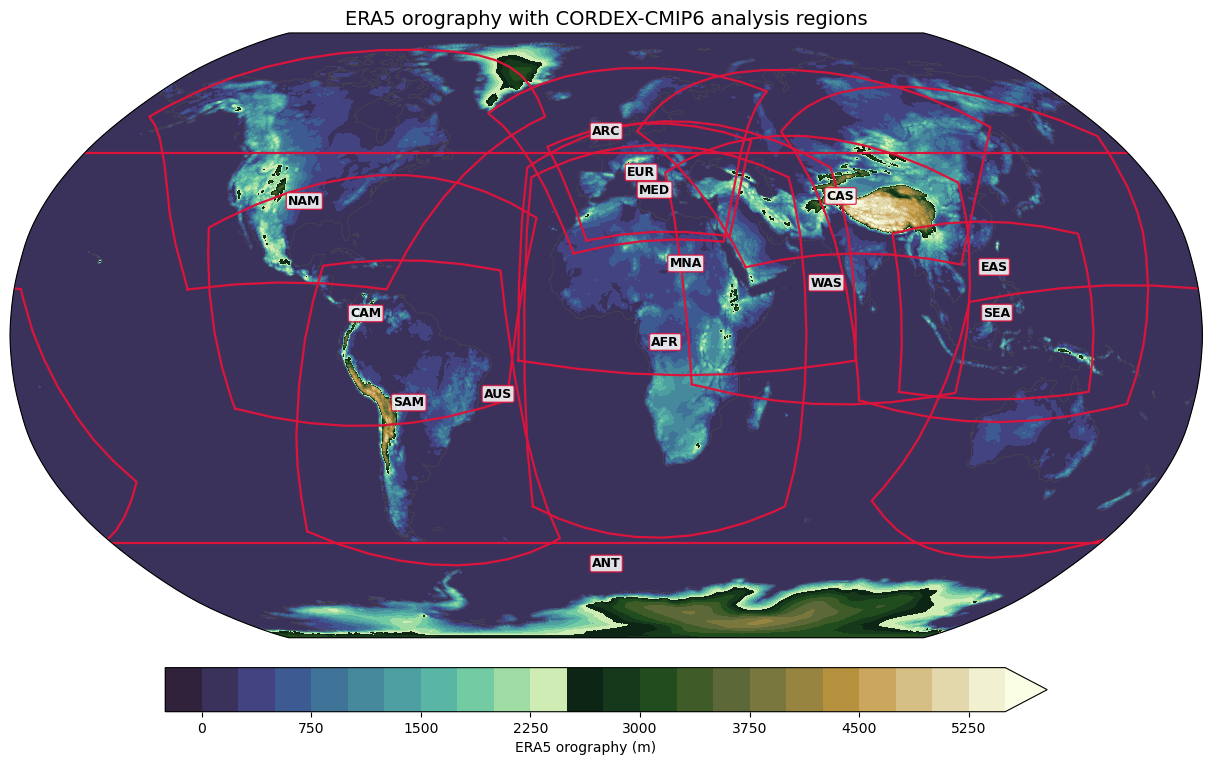

In [12]:
proj = ccrs.Robinson(central_longitude=0)
fig, ax = plt.subplots(figsize=(15, 8), subplot_kw={"projection": proj})
ax.set_global()

# Orography (clip at 0 so the ocean reads as flat sea level).
#levels = np.arange(0, 5501, 250)
levels = np.arange(-250, 5501, 250)
cf = ax.tricontourf(
    lon, lat, orog.values,
#    np.clip(orog.values, 0, None),
    levels=levels, cmap="cmo.topo", extend="max",
    transform=ccrs.PlateCarree(),
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.3")

# CORDEX region outlines.
for name in list_regions():
    lons, lats, tr, llon, llat = region_outline(name)
    ax.plot(lons, lats, transform=tr, color="crimson", linewidth=1.6)
    ax.text(
        llon, llat, name, transform=ccrs.PlateCarree(),
        ha="center", va="center", fontsize=9, fontweight="bold",
        color="black",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="crimson", alpha=0.85),
    )

cbar = fig.colorbar(cf, ax=ax, orientation="horizontal", shrink=0.6, pad=0.04)
cbar.set_label("ERA5 orography (m)")
ax.set_title("ERA5 orography with CORDEX-CMIP6 analysis regions", fontsize=14)

fig.tight_layout()
plt.show()

### Notes

* The polygon outlines are 4-corner quadrilaterals, so strongly rotated domains
  (e.g. EUR) slightly under-cover near the bowed mid-edges — this matches the
  approximation used by `region_mask` for regional statistics.
* To save instead of show, swap the last line for
  `fig.savefig("era5_orography_cordex.png", dpi=150, bbox_inches="tight")`.
* `region_mask(lat, lon, name)` from the same module gives the boolean grid mask
  if you want to *select* points inside a region rather than just outline it.